Imports & Load Data

In [2]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from tqdm import tqdm

# Path to your Parquet file
PARQUET_PATH = "combined_raw_with_windows.parquet"

# Read only necessary columns (lightweight)
cols = ['frame.time', 'label']
df = pd.read_parquet(PARQUET_PATH, columns=cols)
print(f"Loaded {len(df):,} rows.")

# Ensure datetime
df['frame.time'] = pd.to_datetime(df['frame.time'])

# Global time range
min_time = df['frame.time'].min()
max_time = df['frame.time'].max()
total_span = (max_time - min_time).total_seconds()
print(f"Time span: {total_span/3600:.2f} hours")

Loaded 35,134,281 rows.
Time span: 265.10 hours


Define All Configurations (non‑overlap + sliding)

In [4]:
# Define configurations: (name, window_seconds, stride_seconds)
configs = [
    ("60s non-overlap", 60, 60),
    ("30s non-overlap", 30, 30),
    ("10s non-overlap", 10, 10),
    ("60s with 30s stride", 60, 30),
    ("60s with 10s stride", 60, 10),
    ("60s with 5s stride", 60, 5),
    ("30s with 10s stride", 30, 10),
    ("30s with 5s stride", 30, 5),
    ("10s with 5s stride", 10, 5),
]

# Separating non-overlapping for exact calculation
non_overlap = [c for c in configs if c[1] == c[2]]
sliding = [c for c in configs if c[1] != c[2]]

print(f"Non-overlapping configs: {len(non_overlap)}")
print(f"Sliding configs: {len(sliding)}")

Non-overlapping configs: 3
Sliding configs: 6


Exact Counts for Non‑Overlapping Windows

In [8]:
def exact_counts(df, window_sec):
    """Return total windows, attack windows, and per‑class window counts for non‑overlapping windows."""
    win_col = f'win_{window_sec}s'
    df_copy = df.copy()
    df_copy[win_col] = df_copy['frame.time'].dt.floor(f'{window_sec}s')
    grouped = df_copy.groupby(win_col)['label'].agg(lambda x: set(x))
    total_windows = len(grouped)
    attack_windows = 0
    attack_counts = Counter()
    for labels in grouped:
        attack_types = [l for l in labels if l != 'Benign']
        if attack_types:
            attack_windows += 1
            for atk in attack_types:
                attack_counts[atk] += 1
    return total_windows, attack_windows, attack_counts

# Process non-overlapping
non_overlap_results = []
for name, win, stride in non_overlap:
    total, attack_win, counts = exact_counts(df, win)
    non_overlap_results.append({
        'name': name,
        'total_windows': total,
        'attack_windows': attack_win,
        'counts': counts
    })
    print(f"{name}: {total} windows")

60s non-overlap: 673 windows
30s non-overlap: 1332 windows
10s non-overlap: 3960 windows


EXACT COUNTS FOR SLIDING WINDOWS (full dataset)

In [ ]:
df['frame.time'] = pd.to_datetime(df['frame.time'])
min_time = df['frame.time'].min()
max_time = df['frame.time'].max()

sliding_configs = [
    ("60s with 30s stride", 60, 30),
    ("60s with 10s stride", 60, 10),
    ("60s with 5s stride", 60, 5),
    ("30s with 10s stride", 30, 10),
    ("30s with 5s stride", 30, 5),
    ("10s with 5s stride", 10, 5),
]

def exact_sliding_counts(df, win_sec, stride):
    start_ts = min_time.floor(f'{stride}s')
    all_starts = pd.date_range(start=start_ts, end=max_time, freq=f'{stride}s')
    all_starts = [w for w in all_starts if w <= max_time]
    
    df_sorted = df.sort_values('frame.time').reset_index(drop=True)
    time_ns = df_sorted['frame.time'].astype('int64').to_numpy()
    
    start_ns = np.array([pd.Timestamp(w).value for w in all_starts], dtype=np.int64)
    end_ns = start_ns + win_sec * 1_000_000_000
    
    start_positions = np.searchsorted(time_ns, start_ns, side='left')
    end_positions = np.searchsorted(time_ns, end_ns, side='left')
    
    attack_windows = set()
    benign_windows = set()
    attack_window_sets = defaultdict(set)
    
    for win_idx, win in enumerate(all_starts):
        if start_positions[win_idx] == end_positions[win_idx]:
            continue  # empty window
        # Slice data for this window
        df_win = df_sorted.iloc[start_positions[win_idx]:end_positions[win_idx]]
        labels = set(df_win['label'].unique())
        if 'Benign' in labels and len(labels) == 1:
            benign_windows.add(win)
        else:
            # contains at least one attack
            attack_windows.add(win)
            for lab in labels:
                if lab != 'Benign':
                    attack_window_sets[lab].add(win)
    
    # Per‑class counts
    per_class_counts = {lab: len(wins) for lab, wins in attack_window_sets.items()}
    
    total_windows = len(all_starts)
    non_empty = len(attack_windows) + len(benign_windows)
    attack_win_count = len(attack_windows)
    benign_win_count = len(benign_windows)
    
    return total_windows, non_empty, attack_win_count, benign_win_count, per_class_counts

sliding_results = []
for name, win, stride in sliding_configs:
    print(f"Computing exact counts for {name}...")
    total, non_empty, attack_win, benign_win, counts = exact_sliding_counts(df, win, stride)
    sliding_results.append({
        'name': name,
        'total_windows': total,
        'non_empty': non_empty,
        'attack_windows': attack_win,
        'benign_windows': benign_win,
        'counts': counts
    })
    print(f"{name}: {total} total, {non_empty} non‑empty, {attack_win} attack, {benign_win} benign‑only")

results = non_overlap_results + sliding_results

print("\n" + "="*100)
print("SUMMARY: Window Configurations and Attack Coverage (EXACT COUNTS)")
print("="*100)
print(f"{'Configuration':<25} {'Total Win':>10} {'Non‑empty':>10} {'Attack Win':>10} {'Benign Win':>10} {'Min Class':>10} {'Median':>10} {'Max Class':>10}")
print("-"*100)

for r in results:
    counts = r['counts']
    if counts:
        vals = list(counts.values())
        min_c = min(vals)
        median_c = int(np.median(vals))
        max_c = max(vals)
    else:
        min_c = median_c = max_c = 0
    
    if 'non_empty' in r:
        non_empty = r['non_empty']
        benign_win = r['benign_windows']
    else:
        non_empty = r['total_windows']
        benign_win = non_empty - r['attack_windows']  # attack_windows is already computed
    print(f"{r['name']:<25} {r['total_windows']:>10} {non_empty:>10} {r['attack_windows']:>10} {benign_win:>10} {min_c:>10} {median_c:>10} {max_c:>10}")



Computing exact counts for 60s with 30s stride...
60s with 30s stride: 31814 total, 1346 non‑empty, 521 attack, 825 benign‑only
Computing exact counts for 60s with 10s stride...
60s with 10s stride: 95438 total, 4035 non‑empty, 1571 attack, 2464 benign‑only
Computing exact counts for 60s with 5s stride...
60s with 5s stride: 190875 total, 8070 non‑empty, 3148 attack, 4922 benign‑only
Computing exact counts for 30s with 10s stride...
30s with 10s stride: 95438 total, 3995 non‑empty, 1526 attack, 2469 benign‑only
Computing exact counts for 30s with 5s stride...
30s with 5s stride: 190875 total, 7990 non‑empty, 3058 attack, 4932 benign‑only
Computing exact counts for 10s with 5s stride...
10s with 5s stride: 190875 total, 7918 non‑empty, 2563 attack, 5355 benign‑only

SUMMARY: Window Configurations and Attack Coverage (EXACT COUNTS)
Configuration              Total Win  Non‑empty Attack Win Benign Win  Min Class     Median  Max Class
-------------------------------------------------------

Heatmap: Per‑Class Window Counts

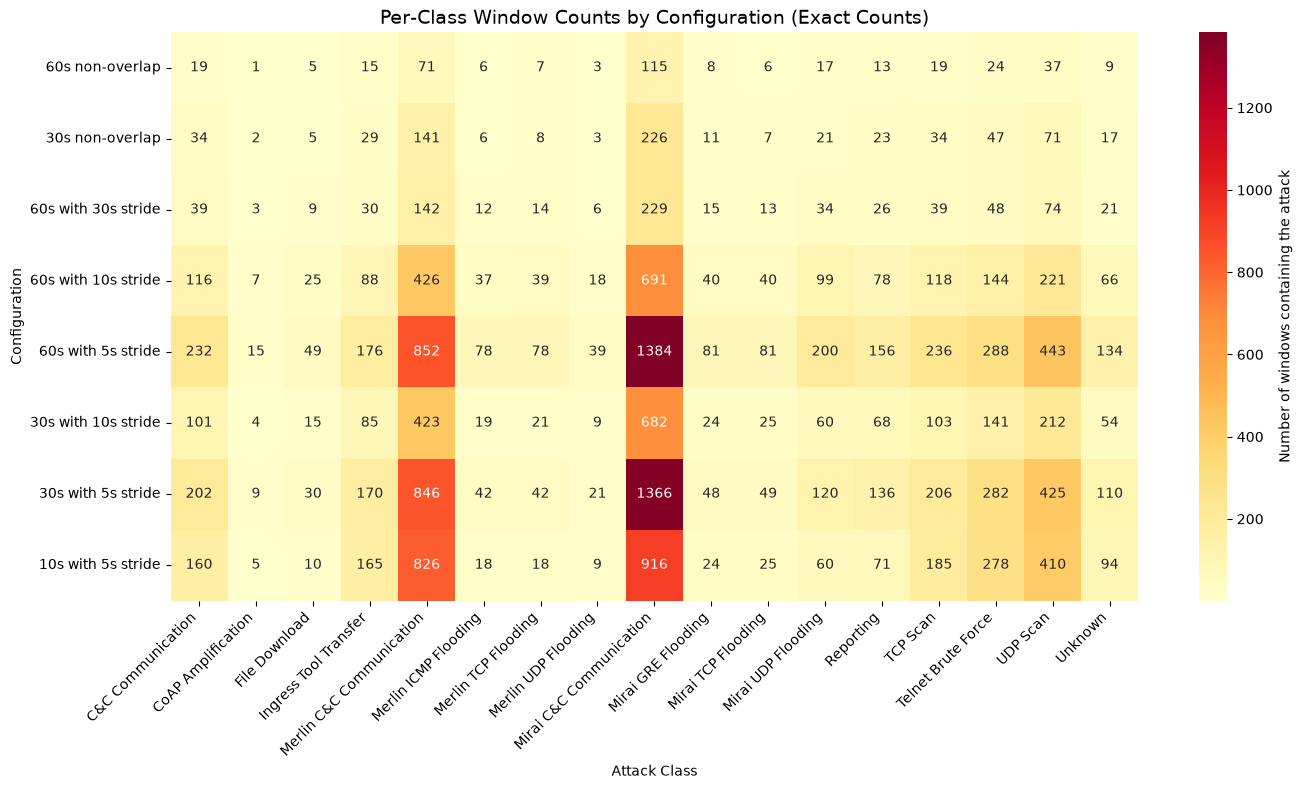

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Build a DataFrame for the heatmap
attack_names = sorted(set().union(*[r['counts'].keys() for r in results]))
config_names = [r['name'] for r in results]

# Create a matrix
data = []
for r in results:
    counts = r['counts']
    row = [counts.get(atk, 0) for atk in attack_names]
    data.append(row)

df_heatmap = pd.DataFrame(data, index=config_names, columns=attack_names)

# Plot
plt.figure(figsize=(14, 8))
sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of windows containing the attack'})
plt.title('Per‑Class Window Counts by Configuration (Exact Counts)', fontsize=14)
plt.xlabel('Attack Class')
plt.ylabel('Configuration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('window_coverage_heatmap_exact.png', dpi=150)
plt.show()

Summary Statistics Plot (Min / Median / Max per Config)


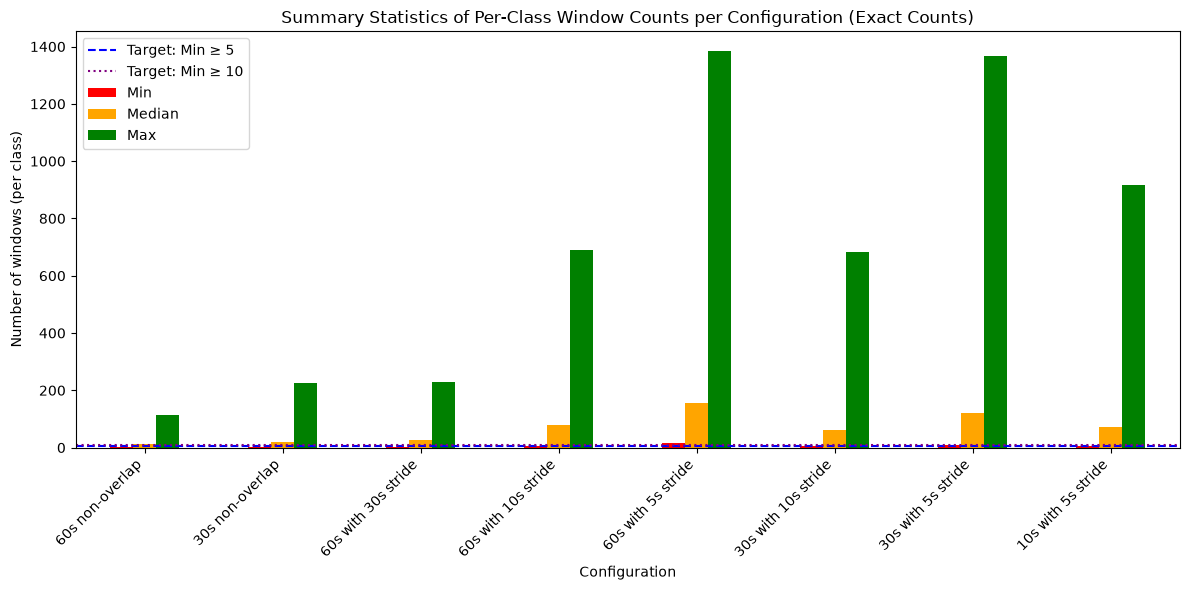

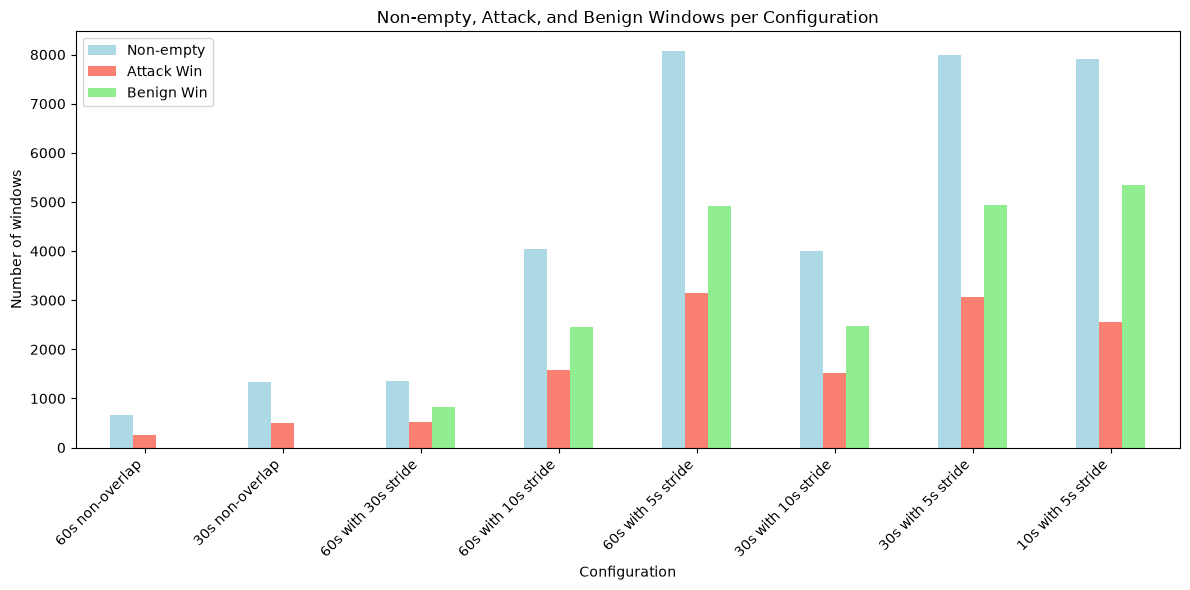

In [10]:
# Compute min, median, max per config
stats = []
for r in results:
    vals = list(r['counts'].values())
    if vals:
        stats.append([
            r['name'],
            min(vals),
            int(np.median(vals)),
            max(vals),
            r['total_windows'],
            r.get('non_empty', r['total_windows']),   # non‑overlap: total = non‑empty
            r['attack_windows'],
            r.get('benign_windows', 0)
        ])
    else:
        stats.append([r['name'], 0, 0, 0, r['total_windows'], r.get('non_empty', r['total_windows']), r['attack_windows'], r.get('benign_windows', 0)])

stats_df = pd.DataFrame(stats, columns=[
    'Configuration', 'Min', 'Median', 'Max', 'Total Win', 'Non‑empty', 'Attack Win', 'Benign Win'
])
stats_df.set_index('Configuration', inplace=True)

# Plot Min / Median / Max
fig, ax = plt.subplots(figsize=(12, 6))
stats_df[['Min', 'Median', 'Max']].plot(kind='bar', ax=ax, color=['red', 'orange', 'green'])
ax.set_title('Summary Statistics of Per‑Class Window Counts per Configuration (Exact Counts)')
ax.set_ylabel('Number of windows (per class)')
ax.set_xlabel('Configuration')
ax.axhline(y=5, color='blue', linestyle='--', label='Target: Min ≥ 5')
ax.axhline(y=10, color='purple', linestyle=':', label='Target: Min ≥ 10')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('window_stats_summary_exact.png', dpi=150)
plt.show()

# Optionally, also show the count of non‑empty / attack windows in a separate plot
fig, ax = plt.subplots(figsize=(12, 6))
stats_df[['Non‑empty', 'Attack Win', 'Benign Win']].plot(kind='bar', ax=ax, color=['lightblue', 'salmon', 'lightgreen'])
ax.set_title('Non‑empty, Attack, and Benign Windows per Configuration')
ax.set_ylabel('Number of windows')
ax.set_xlabel('Configuration')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('window_breakdown_exact.png', dpi=150)
plt.show()